# CSE-CIC-IDS2018 — MLP (Deep Learning Baseline) with Optuna

Optimized to run **locally** (VS Code / Jupyter) — no Google Colab dependencies.

**Why this notebook is separate from `04_Model_Training_Optuna.ipynb`:** that notebook lets
Optuna pick the best 3 among tree-based/boosting algorithms (DecisionTree, RandomForest,
HistGradientBoosting, XGBoost, AdaBoost) — models that are well suited to tabular data and
generally outperform neural networks on this kind of problem. MLP is reported here
**independently**, as a deep-learning reference point, not as a competitor for that "top 3" slot.
It's genuinely useful to know whether deep learning offers anything here — and if it
underperforms the tree ensembles, that itself is a legitimate, expected finding worth reporting
honestly rather than omitting.

**Pipeline covered here:**
1. Load the same `balanced_train_selected.parquet` / `test_selected.parquet` used by notebook 04
2. **Feature scaling** — MLPs are sensitive to feature scale in a way tree models are not, so this
   step (not needed anywhere else in the pipeline) matters a lot here
3. A lightweight Optuna search over MLP architecture + training hyperparameters, so the eventual
   comparison against the tree ensembles is a fair one, not "MLP with arbitrary defaults"
4. Retrain the best configuration on the full training set, evaluate on the real test set
5. Save metrics in the same format as notebook 04 — `05_Compare_All_Models.ipynb` already
   discovers models automatically from `*_metrics.csv` files, so this MLP result will show up in
   that comparison with no changes needed there

## 1. Configuration & Setup

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import time
import json

In [2]:
import time
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

import optuna
from optuna.samplers import TPESampler

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

m:\IDS\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
PROJECT_PATH = Path(r"M:\IDS\c_filesnew")

PROCESSED_DATA_PATH = PROJECT_PATH / "Processed_Data"
RESULTS_PATH = PROJECT_PATH / "Results"
MODELS_PATH  = RESULTS_PATH / "Models"
FIGURES_PATH = RESULTS_PATH / "Figures"
TABLES_PATH  = RESULTS_PATH / "Tables"

for p in [MODELS_PATH, FIGURES_PATH, TABLES_PATH]:
    p.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
CV_FOLDS = 2
N_TRIALS = 25           # MLP trials are slower than tree models, so fewer trials than notebook 04
HPO_SAMPLE_SIZE = 30_000  # rows used for the Optuna search (full data used for final training)
HPO_MAX_ITER = 100        # bounded epoch budget during search, so a bad trial can't run forever
FINAL_MAX_ITER = 800      # the final retrained model gets more iterations to fully converge

## 2. Load Data & Scale Features

MLPs (unlike tree-based models) are sensitive to feature scale — a feature ranging in the millions (e.g. `Flow Duration`) would otherwise dominate the network's gradients over a feature ranging 0-1. `StandardScaler` is fit on the training set only, then applied to both.

In [4]:
train = pd.read_parquet(PROCESSED_DATA_PATH / "balanced_train_selected.parquet")
test = pd.read_parquet(PROCESSED_DATA_PATH / "test_selected.parquet")

X_train = train.drop(columns=["Label"])
y_train = train["Label"]

X_test = test.drop(columns=["Label"])
y_test = test["Label"]

N_CLASSES = y_train.nunique()

print("Train:", X_train.shape, " Test:", X_test.shape, " Classes:", N_CLASSES)

Train: (281295, 30)  Test: (200498, 30)  Classes: 15


In [5]:
from sklearn.utils import resample

MLP_MIN_CLASS_SIZE = 5_000  # rare classes get topped up to at least this many rows via duplication

class_counts = y_train.value_counts()
rows_to_add = []

for label, count in class_counts.items():
    if count < MLP_MIN_CLASS_SIZE:
        class_rows = train[train["Label"] == label]
        extra = resample(class_rows, replace=True, n_samples=MLP_MIN_CLASS_SIZE - count, random_state=RANDOM_STATE)
        rows_to_add.append(extra)

if rows_to_add:
    train_mlp = pd.concat([train] + rows_to_add, ignore_index=True)
    X_train = train_mlp.drop(columns=["Label"])
    y_train = train_mlp["Label"]
    print("MLP-specific oversampling applied. New class counts:")
    print(y_train.value_counts())

MLP-specific oversampling applied. New class counts:
Label
0     100000
4      33844
6      29171
8      22017
1      14293
12     10000
14     10000
9      10000
3      10000
2      10000
10     10000
7       8396
11      7968
5       5536
13      5000
Name: count, dtype: int64


In [6]:
from sklearn.preprocessing import RobustScaler 

scaler = StandardScaler()  # was StandardScaler() 
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

joblib.dump(scaler, MODELS_PATH / "MLP_StandardScaler.pkl")
print("Scaler fit on training data and saved (needed again at inference time).")

Scaler fit on training data and saved (needed again at inference time).


In [7]:
# Stratified subsample for the Optuna search
if len(X_train_scaled) > HPO_SAMPLE_SIZE:
    X_hpo, _, y_hpo, _ = train_test_split(
        X_train_scaled, y_train,
        train_size=HPO_SAMPLE_SIZE,
        stratify=y_train,
        random_state=RANDOM_STATE,
    )
else:
    X_hpo, y_hpo = X_train_scaled, y_train

print("HPO search sample:", X_hpo.shape)

HPO search sample: (30000, 30)


## 3. Optuna Search Space (Architecture + Training Hyperparameters)

In [8]:
def build_mlp(trial, max_iter):
    n_layers = trial.suggest_int("n_layers", 1, 4)
    hidden_layer_sizes = tuple(
        trial.suggest_int(f"n_units_l{i}", 32, 384, step=32) for i in range(n_layers)
    )

    activation = trial.suggest_categorical("activation", ["relu", "tanh"])
    alpha = trial.suggest_float("alpha", 1e-6, 1.0, log=True)
    learning_rate_init = trial.suggest_float("learning_rate_init", 1e-4, 1e-1, log=True)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256, 512])

    return MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        activation=activation,
        solver='adam',
        alpha=alpha,
        learning_rate_init=learning_rate_init,
        batch_size=batch_size,
        max_iter=max_iter,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=15,
        random_state=RANDOM_STATE,
    )

## 4. Optuna Study

In [9]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

def objective(trial):
    #min_class_size = trial.suggest_int("min_class_size", 2000, 12000, step=1000)
    model = build_mlp(trial, max_iter=HPO_MAX_ITER)
    scores = cross_val_score(
        model, X_hpo, y_hpo,
        cv=cv, scoring="f1_macro", n_jobs=-1,
    )
    return float(scores.mean())

In [10]:
study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE),
    study_name="mlp_hyperparameter_search",
    storage="sqlite:///mlp_optuna_study.db",
    load_if_exists=True,

)

study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("Best trial:")
print("  Value (macro F1):", study.best_value)
print("  Params:", study.best_params)

Best trial: 72. Best value: 0.898714: 100%|██████████| 25/25 [41:51<00:00, 100.45s/it] 

Best trial:
  Value (macro F1): 0.8987142273709234
  Params: {'n_layers': 2, 'n_units_l0': 224, 'n_units_l1': 384, 'activation': 'relu', 'alpha': 0.0001703619367708789, 'learning_rate_init': 0.0008797046978422353, 'batch_size': 64}


In [11]:
joblib.dump(study, MODELS_PATH / "mlp_optuna_study.pkl")

trials_df = study.trials_dataframe()
trials_df.to_csv(TABLES_PATH / "mlp_optuna_trials.csv", index=False)
trials_df.sort_values("value", ascending=False).head()

,number,value,datetime_start,datetime_complete,duration,params_activation,params_alpha,params_batch_size,params_learning_rate_init,params_n_layers,params_n_units_l0,params_n_units_l1,params_n_units_l2,params_n_units_l3,state
72,72,0.898714,2026-07-25 20:58:40.156136,2026-07-25 21:06:03.980161,0 days 00:07:23.824025,relu,0.000170,64,0.000880,2,224,384.0,NaN,NaN,COMPLETE
63,63,0.896235,2026-07-25 20:35:50.037203,2026-07-25 20:37:50.279846,0 days 00:02:00.242643,relu,0.000059,64,0.000937,2,128,64.0,NaN,NaN,COMPLETE
32,32,0.896037,2026-07-25 18:47:18.812644,2026-07-25 18:48:37.387722,0 days 00:01:18.575078,relu,0.003580,64,0.000806,2,160,128.0,NaN,NaN,COMPLETE
36,36,0.894491,2026-07-25 18:50:43.285213,2026-07-25 18:51:31.094304,0 days 00:00:47.809091,relu,0.003956,64,0.002083,2,96,192.0,NaN,NaN,COMPLETE
73,73,0.893906,2026-07-25 21:06:04.090771,2026-07-25 21:12:58.578565,0 days 00:06:54.487794,relu,0.000035,64,0.000830,2,224,384.0,NaN,NaN,COMPLETE


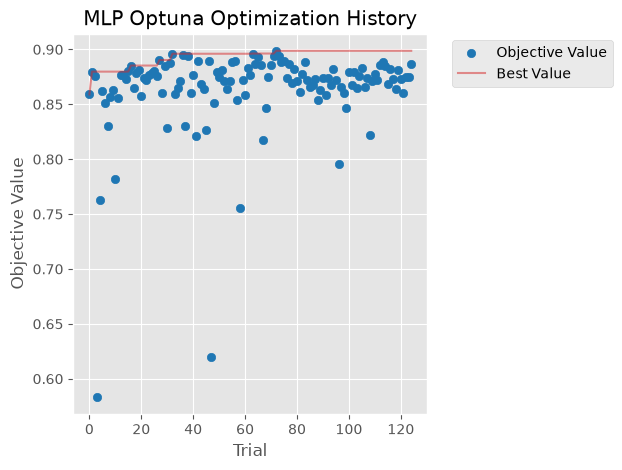

In [12]:
ax = optuna.visualization.matplotlib.plot_optimization_history(study)
ax.set_title("MLP Optuna Optimization History")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "mlp_optuna_optimization_history.png", dpi=200, bbox_inches="tight")
plt.show()

## 5. Retrain the Best MLP on the Full Training Set

In [13]:
def evaluate_model(model, model_name, X_train, y_train, X_test, y_test):
    print("="*70)
    print(f"Training {model_name}")
    print("="*70)

    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    start = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - start

    accuracy = accuracy_score(y_test, y_pred)
    precision_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
    recall_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)
    macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    report_df = pd.DataFrame(
        classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    ).transpose()
    report_df.to_csv(MODELS_PATH / f"{model_name}_classification_report.csv")

    metrics_df = pd.DataFrame({
        "Model": [model_name],
        "Accuracy": [accuracy],
        "Macro Precision": [precision_macro],
        "Macro Recall": [recall_macro],
        "Macro F1": [macro_f1],
        "Weighted F1": [weighted_f1],
        "Training Time (s)": [train_time],
        "Prediction Time (s)": [pred_time],
    })
    metrics_df.to_csv(MODELS_PATH / f"{model_name}_metrics.csv", index=False)

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 10))
    ConfusionMatrixDisplay(cm).plot(cmap="Blues", values_format="d")
    plt.title(model_name)
    plt.savefig(MODELS_PATH / f"{model_name}_confusion_matrix.png", dpi=300, bbox_inches="tight")
    plt.close()

    joblib.dump(model, MODELS_PATH / f"{model_name}.pkl")

    print(metrics_df)
    return metrics_df

In [14]:
class _FixedTrial:
    """Lets us reuse build_mlp() with a fixed, already-known set of params (no new suggestions)."""
    def __init__(self, params):
        self.params = params
    def suggest_int(self, name, *a, **k):
        return self.params[name]
    def suggest_categorical(self, name, *a, **k):
        return self.params[name]
    def suggest_float(self, name, *a, **k):
        return self.params[name]

best_model = build_mlp(_FixedTrial(study.best_params), max_iter=FINAL_MAX_ITER)

with open(MODELS_PATH / "MLP_Tuned_best_params.json", "w") as f:
    json.dump(study.best_params, f, indent=2, default=str)

mlp_metrics = evaluate_model(
    best_model, "MLP_Tuned",
    X_train_scaled, y_train,
    X_test_scaled, y_test,
)

Training MLP_Tuned
       Model  Accuracy  Macro Precision  Macro Recall  Macro F1  Weighted F1  \
0  MLP_Tuned  0.981456         0.752465      0.812275  0.737305     0.981138   

   Training Time (s)  Prediction Time (s)  
0         9211.98159             46.59217  


<Figure size 1000x1000 with 0 Axes>

In [15]:
y_train_pred = best_model.predict(X_train_scaled)

train_accuracy = accuracy_score(y_train, y_train_pred)
train_macro_f1 = f1_score(y_train, y_train_pred, average="macro", zero_division=0)

print(f"Training Accuracy : {train_accuracy:.4f}")
print(f"Training Macro F1  : {train_macro_f1:.4f}")
print(f"Test Accuracy      : {mlp_metrics['Accuracy'].iloc[0]:.4f}")
print(f"Test Macro F1      : {mlp_metrics['Macro F1'].iloc[0]:.4f}")

if train_accuracy - mlp_metrics['Accuracy'].iloc[0] > 0.05:
    print("\nNote: training accuracy is notably higher than test accuracy — possible overfitting.")

Training Accuracy : 0.9539
Training Macro F1  : 0.9198
Test Accuracy      : 0.9815
Test Macro F1      : 0.7373


---
**Outputs (under `Results/`):**
- `Models/mlp_optuna_study.pkl`, `Tables/mlp_optuna_trials.csv` — the full Optuna search
- `Models/MLP_StandardScaler.pkl` — **required at inference time**; any new data must be scaled
  with this same fitted scaler before being passed to `MLP_Tuned.pkl`
- `Models/MLP_Tuned.pkl`, `_metrics.csv`, `_classification_report.csv`, `_confusion_matrix.png`,
  `_best_params.json`

Since `05_Compare_All_Models.ipynb` discovers models by scanning for `*_metrics.csv` files,
`MLP_Tuned_metrics.csv` will automatically appear in that notebook's comparison table and charts
the next time it's run — no changes needed there.